In [1]:
# ==============================
# STEP 0: Setup Kaggle API
# ==============================
import json
import os

kaggle_dict = {
    "username": "Sathya Mozhi",  # replace with your Kaggle username
    "key": "KGAT_a441b02dfc006e7ccb28cb7260013171"         # replace with your Kaggle API key
}

with open("kaggle.json", "w") as file:
    json.dump(kaggle_dict, file)

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download PIMA Diabetes dataset
!kaggle datasets download -d uciml/pima-indians-diabetes-database
!unzip -o pima-indians-diabetes-database.zip

Dataset URL: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
License(s): CC0-1.0
  0% 0.00/8.91k [00:00<?, ?B/s]
100% 8.91k/8.91k [00:00<00:00, 33.2MB/s]
Archive:  pima-indians-diabetes-database.zip
  inflating: diabetes.csv            


In [2]:
# ==============================
# STEP 1: Import Libraries
# ==============================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

In [3]:
# ==============================
# STEP 2: Load the dataset
# ==============================
df = pd.read_csv("diabetes.csv")  # file from unzipped dataset
print("Original Dataset (First 5 rows):")
print(df.head())
print("\nShape:", df.shape)

Original Dataset (First 5 rows):
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Shape: (768, 9)


In [4]:
# ==============================
# STEP 3: Check for Missing Values
# ==============================
print("\nMissing values per column:\n", df.isna().sum())

# If any missing values exist, fill with mean
df = df.fillna(df.mean())


Missing values per column:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [5]:
# ==============================
# STEP 4: Features & Target
# ==============================
X = df.drop("Outcome", axis=1)  # features
y = df["Outcome"]               # target

print("\nFeatures (first 5 rows):")
print(X.head())
print("\nTarget distribution:")
print(y.value_counts())


Features (first 5 rows):
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  

Target distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


In [6]:
# ==============================
# STEP 5: Train‑Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
# ==============================
# STEP 6: Train Decision Tree
# ==============================
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train, y_train)

# Predict
y_pred = dt.predict(X_test)

In [8]:
# ==============================
# STEP 7: Evaluate Model
# ==============================
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Decision Tree Accuracy:", acc)
print("Confusion Matrix:\n", cm)

Decision Tree Accuracy: 0.7922077922077922
Confusion Matrix:
 [[87 12]
 [20 35]]


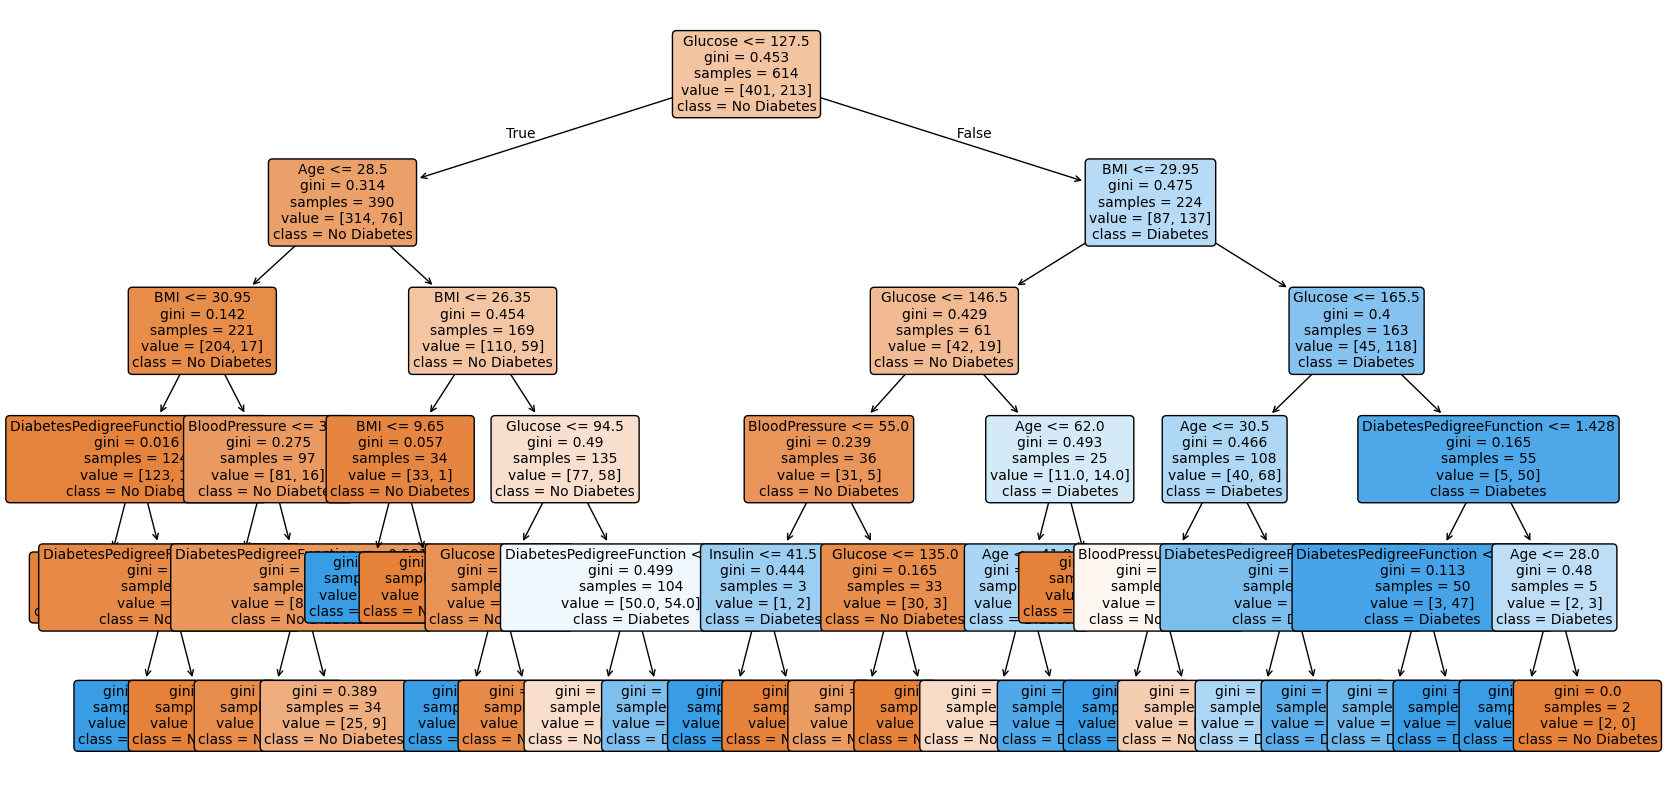

In [9]:
# ==============================
# STEP 8: Visualize Decision Tree
# ==============================
plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=X.columns, class_names=["No Diabetes", "Diabetes"],
          filled=True, rounded=True, fontsize=10)
plt.show()

In [10]:
# ==============================
# STEP 9: Predict New Input
# ==============================
# Example new patient input (features must match order of X columns)
new_input = pd.DataFrame([{
    "Pregnancies": 2,
    "Glucose": 135,
    "BloodPressure": 80,
    "SkinThickness": 30,
    "Insulin": 130,
    "BMI": 33.0,
    "DiabetesPedigreeFunction": 0.5,
    "Age": 40
}])

prediction = dt.predict(new_input)
print("Prediction for new patient:", "Diabetes" if prediction[0]==1 else "No Diabetes")

Prediction for new patient: Diabetes
